Linear regression can also be implemented using premade libraries. Here all the calculations are abstracted by the library.

In [2]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.1 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/8.2 MB 2.1 MB/s eta 0:00:04
   ----- ---------------------------------- 1.0/8.2 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.2 MB 1.8 MB/s eta 0:00:04
   ----------- ---------------------------- 2.4/8.2 MB 2.1 MB/s eta 0:00:03
   -------------- ------------------------- 2.9/8.2 MB 2.3 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 2.0 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 2.0 MB/s eta 0:00:03
   -------------------- ------------------- 4.2/8.2 MB 2.2 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.2 MB 2.2 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 2.3 MB/s eta 0:00:02
   -----------------------


[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

<Axes: xlabel='TV', ylabel='Sales'>

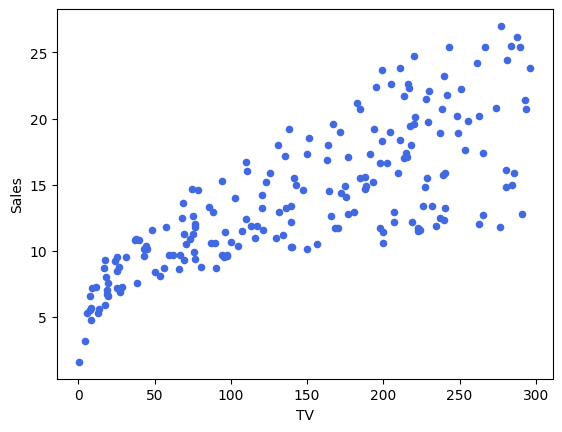

In [13]:
# Load the data
df = pd.read_csv('./Datasets/tvmarketing.csv')
X = df["TV"]
Y = df["Sales"] 
df.plot(x="TV",y="Sales",kind="scatter",color="royalblue")

We can normalize the data if we want to.

## Linear Regression Using NumPy

In [ ]:
m_numpy, b_numpy = np.polyfit(X, Y, 1)

print(f"Linear regression with NumPy. Slope: {m_numpy}. Intercept: {b_numpy}")

Linear regression with NumPy. Slope: 0.04753664043301972. Intercept: 7.032593549127696


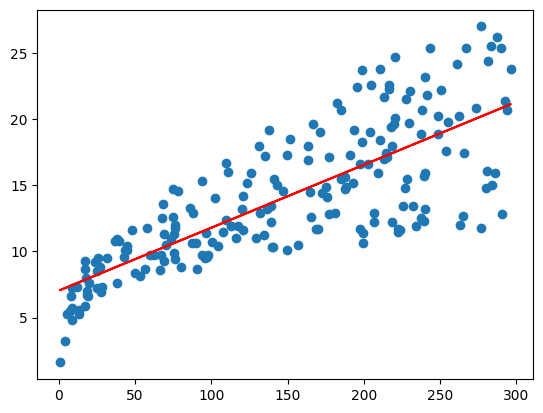

In [17]:
plt.scatter(X,Y)
Y_pred = m_numpy*X + b_numpy
plt.plot(X,Y_pred,c="red")

## Linear regression Using Scikit Learn

In [8]:
lr_sklearn = LinearRegression()
print(f"Shape of X array: {X.shape}")
print(f"Shape of Y array: {Y.shape}")
try:
    lr_sklearn.fit(X, Y)
except ValueError as err:
    print(err)

Shape of X array: (200,)
Shape of Y array: (200,)
Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.


This error occurs because X is a Pandas Series (1D), but LinearRegression expects X to be 2D. we can reshape Y too but it is not necessary.

In [14]:
# Solution 1: turn X and Y to Dataframe
X = X.to_frame()

# Solution 2: reshape the data
# X_sklearn = X.values.reshape(-1, 1)

# or
# X_sklearn = X[:, np.newaxis]
 

In [16]:
lr_sklearn.fit(X, Y)
m_sklearn = lr_sklearn.coef_
b_sklearn = lr_sklearn.intercept_


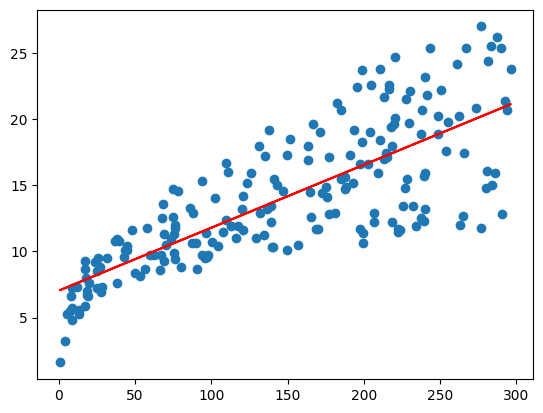

In [18]:
plt.scatter(X,Y)
Y_pred = m_sklearn*X + b_sklearn
plt.plot(X,Y_pred,c="red")